# TPI 1 — Adquisición y Análisis Lingüístico de Medios
**Modalidad:** Trabajo Práctico Individual · PLN 2026

---
## Guía de uso
| Símbolo | Significado |
|---|---|
| ▶ | Celda de código lista para ejecutar |
| 💡 Por qué | Decisión de diseño explicada |
| ⚠️ | Celda lenta o que requiere internet |
| 🧪 | Celda de verificación independiente |

**Orden recomendado:** ejecutá las celdas de arriba hacia abajo.  
Podés re-ejecutar cualquier celda individual para depurar errores específicos.

## PASO 0 — Instalación de dependencias
⚠️ **Ejecutá esta celda solo una vez.** Puede tardar 2-3 minutos la primera vez.

In [1]:
import sys
# Instalamos todas las libs del TPI en el intérprete actual del notebook
!{sys.executable} -m pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!{sys.executable} -m spacy download es_core_news_lg -q
print("✓ Instalación completa")

c:\Users\User\Documents\navas-jose-pln-1c-2026\004_tpi_1\.venv\Scripts\python.exe: No module named pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
✓ Instalación completa


## Importaciones
▶ **Ejecutá esta celda antes de cualquier otra.** Carga todas las librerías en memoria.

In [2]:
%matplotlib inline
# %matplotlib inline muestra gráficos dentro del notebook (no en ventana externa)

import os
import json
import warnings
warnings.filterwarnings('ignore')  # Suprimimos warnings no críticos

import spacy
import pandas as pd
import trafilatura
import whisper
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud

# CORRECCIÓN: __file__ no existe en notebooks; usamos os.getcwd() en su lugar
CARPETA_PROYECTO = os.getcwd()
print(f"Carpeta de trabajo: {CARPETA_PROYECTO}")
print("✓ Librerías importadas correctamente")

Carpeta de trabajo: c:\Users\User\Documents\navas-jose-pln-1c-2026\004_tpi_1
✓ Librerías importadas correctamente


## Configuración de fuentes de datos
Modificá estas variables para cambiar el corpus sin tocar el resto del código.

💡 **Por qué noticias de tecnología/IA:** el modelo `es_core_news_lg` fue entrenado en noticias.  
Cuanto más cercano sea el dominio al entrenamiento, mejor será el NER.

In [25]:
# URLs de noticias en español — temática IA/tecnología
URLS_NOTICIAS = [
    "https://es.wikipedia.org/wiki/Inteligencia_artificial",
    "https://es.wikipedia.org/wiki/Procesamiento_de_lenguaje_natural",
    "https://es.wikipedia.org/wiki/Periodismo_digital"
]

# ⚠️ Video de YouTube (~3-5 min, español claro). Ponelo en None para saltear.
URL_VIDEO_YOUTUBE = "https://www.youtube.com/results?search_query=el+chambo"

# JSON de corpus previo (se omite automáticamente si no existe)
RUTA_JSON_PREVIO = os.path.join(CARPETA_PROYECTO, "corpus_previo.json")

print(f"URLs: {len(URLS_NOTICIAS)} | Video: {bool(URL_VIDEO_YOUTUBE)} | JSON: {os.path.exists(RUTA_JSON_PREVIO)}")

URLs: 3 | Video: True | JSON: False


---
## Parte 1 — Adquisición Multimodal del Corpus
**Objetivo:** construir tres funciones independientes y unificarlas en un DataFrame.

El pipeline acepta tres fuentes porque en la práctica los corpus mediáticos son heterogéneos:
sitios web, podcasts/videos y bases de datos previas conviven en el mismo análisis.

### 1.1 — Scraping web con Trafilatura
⚠️ Requiere conexión a internet. Las URLs que fallen se omiten sin detener el proceso.

In [26]:
def extraer_noticias_web(urls):
    """Extrae texto limpio de una lista de URLs usando Trafilatura."""
    noticias = []

    for url in urls:                          # Iteramos sobre cada URL de la lista
        try:
            # fetch_url descarga el HTML manejando headers, redirects y cookies
            contenido_html = trafilatura.fetch_url(url)

            if contenido_html:                # Solo procesamos si la descarga tuvo éxito
                texto = trafilatura.extract(
                    contenido_html,
                    include_comments=False,   # Sin comentarios de usuarios (ruido)
                    include_tables=False,     # Sin tablas (datos no narrativos)
                    no_fallback=False,        # Fallback si falla el extractor principal
                    favor_recall=True,        # Priorizamos cantidad sobre precisión
                )

                if texto and len(texto) > 100:  # Descartamos textos demasiado cortos
                    noticias.append({
                        "titulo_o_fuente": url,   # URL como identificador del documento
                        "texto": texto,            # Texto editorial limpio
                        "origen": "web",           # Etiqueta para análisis diferencial
                    })
                    print(f"  ✓ {url[:70]}...")
                else:
                    print(f"  ✗ Texto insuficiente: {url[:50]}")
            else:
                print(f"  ✗ No se pudo descargar: {url[:50]}")

        except Exception as e:
            # try/except por URL: una falla no detiene el loop completo
            print(f"  ✗ Error en {url[:50]}: {e}")

    return noticias

print("Función definida.")

Función definida.


In [19]:
# 🧪 PRUEBA 1.1 — Verificamos el scraping con una sola URL
datos_web_prueba = extraer_noticias_web([URLS_NOTICIAS[0]])

if datos_web_prueba:
    print(f"\nTexto extraído ({len(datos_web_prueba[0]['texto'])} caracteres):")
    print(datos_web_prueba[0]["texto"][:400] + "...")
else:
    print("\n⚠️ No se extrajo texto. Verificá tu conexión a internet.")

  ✓ https://es.wikipedia.org/wiki/Inteligencia_artificial...

Texto extraído (99873 caracteres):
Inteligencia artificial
La inteligencia artificial, abreviado como IA o AI (por su nombre en inglés: artificial intelligence), en el contexto de las ciencias de la computación, es una disciplina y un conjunto de capacidades cognoscitivas e intelectuales expresadas por sistemas informáticos o combinaciones de algoritmos cuyo propósito es la creación de máquinas que imiten la inteligencia humana.
Es...


💡 **Por qué Trafilatura sobre BeautifulSoup:**  
Trafilatura usa algoritmos de densidad de texto para separar el contenido editorial del ruido HTML  
(menús, publicidades, footers). BeautifulSoup requiere personalizar el parser por sitio;  
Trafilatura funciona en cualquier sitio sin configuración adicional.

### 1.2 — Transcripción de audio con Whisper
⚠️ Esta celda descarga el audio y lo transcribe **localmente en tu CPU**.  
Puede tardar **3-8 minutos**. Si querés saltearlo por ahora, ejecutá la celda de prueba que deja `datos_audio = []`.

In [27]:
def transcribir_audio_youtube(url_video):
    """Descarga audio de YouTube y lo transcribe con Whisper."""
    resultado   = []
    nombre_base = "audio_tpi1"
    archivo_mp3 = f"{nombre_base}.mp3"

    try:
        import yt_dlp  # Importación local: no falla el import global si no está

        opciones = {
            "format": "bestaudio/best",         # Mejor calidad de audio disponible
            "outtmpl": nombre_base,              # Nombre base del archivo de salida
            "postprocessors": [{
                "key": "FFmpegExtractAudio",     # FFmpeg convierte a mp3
                "preferredcodec": "mp3",
                "preferredquality": "192",       # 192 kbps: buena calidad, archivo manejable
            }],
            "quiet": True,                       # Sin verbose de yt-dlp
        }

        print("  ⬇ Descargando audio...")
        with yt_dlp.YoutubeDL(opciones) as ydl:
            info   = ydl.extract_info(url_video, download=True)
            titulo = info.get("title", "Video sin título")
        print(f"  ✓ Descargado: {titulo}")

        # Modelos Whisper: 'base' (rápido), 'small' (recomendado), 'medium'/'large' (GPU)
        print("  Cargando modelo Whisper small...")
        modelo = whisper.load_model("small")

        print("  Transcribiendo (puede tardar varios minutos en CPU)...")
        transcripcion = modelo.transcribe(
            archivo_mp3,
            language="es",   # Forzamos español para evitar errores de detección
            fp16=False,       # fp16 solo es útil con GPU CUDA
        )
        texto = transcripcion["text"]  # El texto transcrito está en la clave "text"

        resultado.append({
            "titulo_o_fuente": titulo,
            "texto": texto,
            "origen": "audio",
        })
        print(f"  ✓ Transcripción: {len(texto)} caracteres")

        if os.path.exists(archivo_mp3):    # Eliminamos el mp3 temporal
            os.remove(archivo_mp3)

    except Exception as e:
        print(f"  ✗ Error: {e}")
        print("  → Verificá que FFmpeg esté instalado y la URL sea válida.")

    return resultado

print("Función definida.")

Función definida.


In [29]:
# 🧪 PRUEBA 1.2
# OPCIÓN A: Saltar el audio (más rápido para probar el resto del pipeline)
datos_audio = []
print("Audio salteado — datos_audio = []")
#print("Para transcribir, descomentá la línea de abajo:")
#datos_audio = transcribir_audio_youtube(URL_VIDEO_YOUTUBE)

Audio salteado — datos_audio = []


💡 **Por qué Whisper:**  
Corre 100% localmente sin costo. Tiene WER (Word Error Rate) muy bajo en español.  
Forzar `language='es'` evita confusión cuando el video tiene música de fondo en otro idioma.

### 1.3 — Carga de JSON local
▶ Si no tenés un JSON previo, esta celda crea uno de ejemplo automáticamente.

In [30]:
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en JSON y lo normaliza al esquema estándar."""
    datos = []

    if not os.path.exists(ruta_json):
        print(f"  ℹ JSON no encontrado: {ruta_json} — se omite.")
        return datos

    try:
        with open(ruta_json, "r", encoding="utf-8") as f:
            contenido = json.load(f)        # Parseamos el JSON a estructura Python

        # Normalizamos: el JSON puede ser lista o dict con distintas claves
        if isinstance(contenido, list):
            registros = contenido
        elif isinstance(contenido, dict) and "datos" in contenido:
            registros = contenido["datos"]
        else:
            registros = [contenido]         # Objeto único → lo envolvemos en lista

        for r in registros:
            # Intentamos múltiples nombres de clave para máxima compatibilidad
            texto  = r.get("texto", r.get("content", r.get("body", "")))
            fuente = r.get("titulo", r.get("fuente", r.get("url", "JSON local")))
            if texto and len(texto) > 50:
                datos.append({"titulo_o_fuente": fuente, "texto": texto, "origen": "json"})

        print(f"  ✓ JSON cargado: {len(datos)} registros")

    except json.JSONDecodeError as e:
        print(f"  ✗ JSON inválido: {e}")
    except Exception as e:
        print(f"  ✗ Error: {e}")

    return datos

print("Función definida.")

Función definida.


In [31]:
# 🧪 PRUEBA 1.3 — Creamos un JSON de ejemplo si no existe
JSON_PRUEBA = os.path.join(CARPETA_PROYECTO, 'corpus_previo.json')

if not os.path.exists(JSON_PRUEBA):
    corpus_ejemplo = [
        {
            "titulo": "Qué es la inteligencia artificial",
            "texto": (
                "La inteligencia artificial (IA) es la simulación de procesos de inteligencia humana "
                "por sistemas informáticos. Incluye el aprendizaje, el razonamiento y la autocorrección. "
                "Empresas como Google, Microsoft y OpenAI lideran el desarrollo de estas tecnologías. "
                "En Argentina, el gobierno nacional lanzó un plan de adopción de IA para el sector público."
            )
        },
        {
            "titulo": "IA en el periodismo argentino",
            "texto": (
                "El periodismo enfrenta una transformación profunda debido a la inteligencia artificial. "
                "Medios como La Nación, Infobae y Clarín comenzaron a usar herramientas de IA para "
                "automatizar la generación de noticias. Organizaciones como Chequeado usan sistemas "
                "automáticos para detectar desinformación. La Universidad de Buenos Aires investiga "
                "el impacto de los algoritmos en la agenda mediática argentina."
            )
        },
        {
            "titulo": "Regulación de IA en América Latina",
            "texto": (
                "La Unión Europea aprobó el primer marco regulatorio de inteligencia artificial. "
                "En América Latina, Brasil y Chile avanzan en proyectos de ley similares. "
                "La Argentina, a través del Ministerio de Ciencia y Tecnología, trabaja en lineamientos "
                "éticos para el uso de IA en el Estado. El CONICET y la UBA participan en los debates."
            )
        },
    ]
    with open(JSON_PRUEBA, 'w', encoding='utf-8') as f:
        json.dump(corpus_ejemplo, f, ensure_ascii=False, indent=2)
    print(f"✓ JSON de ejemplo creado: {JSON_PRUEBA}")

datos_json = cargar_json_previo(JSON_PRUEBA)
if datos_json:
    print(f"\nFuente: {datos_json[0]['titulo_o_fuente']}")
    print(datos_json[0]['texto'][:200] + '...')

✓ JSON de ejemplo creado: c:\Users\User\Documents\navas-jose-pln-1c-2026\004_tpi_1\corpus_previo.json
  ✓ JSON cargado: 3 registros

Fuente: Qué es la inteligencia artificial
La inteligencia artificial (IA) es la simulación de procesos de inteligencia humana por sistemas informáticos. Incluye el aprendizaje, el razonamiento y la autocorrección. Empresas como Google, Micros...


### 1.4 — Unificación del corpus
▶ Consolida las tres fuentes en un único DataFrame estandarizado.

💡 **Esquema mínimo común** (`titulo_o_fuente | texto | origen`): las tres fuentes tienen  
metadatos distintos e incomparables. Un esquema mínimo garantiza interoperabilidad.  
La columna `origen` es clave para el análisis diferencial web vs. audio.

In [32]:
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Concatena las tres fuentes en un DataFrame con columnas estándar."""
    todos = datos_web + datos_audio + datos_json  # Concatenamos las tres listas

    if not todos:
        print("  ⚠ Corpus vacío — ninguna fuente devolvió datos.")
        return pd.DataFrame(columns=["titulo_o_fuente", "texto", "origen"])

    df = pd.DataFrame(todos)               # Pandas convierte dicts a columnas

    df = df.dropna(subset=["texto"])        # Filas sin texto
    df = df[df["texto"].str.strip() != ""]  # Textos vacíos o solo espacios

    df["longitud_texto"] = df["texto"].apply(len)  # Útil para análisis posterior
    df = df.reset_index(drop=True)          # Índice limpio y secuencial

    print(f"  ✓ Corpus unificado: {len(df)} documentos")
    print(df["origen"].value_counts().to_frame().to_string())

    return df

print("Función definida.")

Función definida.


In [33]:
# 🧪 PRUEBA 1.4 — Unificamos todas las fuentes
print("[1/3] Scraping web...")
datos_web = extraer_noticias_web(URLS_NOTICIAS)

print("\n[2/3] Audio (saltado)...")
# datos_audio ya está definido arriba ([] o el resultado de transcribir)

print("\n[3/3] JSON local...")
datos_json = cargar_json_previo(RUTA_JSON_PREVIO)

print("\n[4/4] Unificando...")
df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)

print("\n── Vista previa del corpus ──")
df_corpus[["titulo_o_fuente", "origen", "longitud_texto"]].head(10)

[1/3] Scraping web...
  ✓ https://es.wikipedia.org/wiki/Inteligencia_artificial...
  ✓ https://es.wikipedia.org/wiki/Procesamiento_de_lenguaje_natural...
  ✓ https://es.wikipedia.org/wiki/Periodismo_digital...

[2/3] Audio (saltado)...

[3/3] JSON local...
  ✓ JSON cargado: 3 registros

[4/4] Unificando...
  ✓ Corpus unificado: 6 documentos
        count
origen       
web         3
json        3

── Vista previa del corpus ──


,titulo_o_fuente,origen,longitud_texto
0,https://es.wikipedia.org/wiki/Inteligencia_art...,web,99873
1,https://es.wikipedia.org/wiki/Procesamiento_de...,web,9997
2,https://es.wikipedia.org/wiki/Periodismo_digital,web,15912
3,Qué es la inteligencia artificial,json,347
4,IA en el periodismo argentino,json,398
5,Regulación de IA en América Latina,json,325


**⏸ Pausa de auditoría — Parte 1**

> ¿Cómo afectó la falta de puntuación en la transcripción de Whisper vs. el texto de noticias?  
> ¿Perdiste información contextual al aplanar las fuentes a un esquema mínimo?

*Escribí tu respuesta aquí antes de continuar...*

### ¿Cómo afectó la falta de puntuación en la transcripción de Whisper vs. el texto de noticias?

La transcripción de Whisper produce texto continuo con poca o nula puntuación: sin comas, puntos ni mayúsculas en nombres propios. Esto afecta el pipeline de tres formas concretas:

**1. Segmentación de oraciones (parser de spaCy):**
El parser detecta límites de oración usando señales ortográficas (punto seguido, mayúscula inicial). Sin ellas, tiende a producir una única oración gigante por párrafo o a cortar en lugares incorrectos. Esto impacta directamente en la búsqueda por oración del dashboard.

**2. Reconocimiento de entidades (NER):**
El modelo `es_core_news_lg` fue entrenado con texto periodístico donde *"Google"*, *"Argentina"* aparecen con mayúscula. Si Whisper escribe *"google"* o *"argentina"* en minúsculas, el modelo los clasifica peor o directamente los pierde. El NER es muy sensible a la capitalización porque es un feature de alta importancia en el modelo estadístico.

**3. Lematización:**
Tokens sin mayúscula inicial pueden recibir lemas distintos. Por ejemplo, *"estados unidos"* en minúsculas puede ser lematizado como dos sustantivos comunes en lugar de un nombre propio compuesto.

**Conclusión:** el texto web produce NER más preciso y segmentación más limpia. El texto transcrito tiene valor en vocabulario oral e informal, pero penaliza la calidad del análisis lingüístico automático.

---

### ¿Se perdió información contextual al aplanar las fuentes a un esquema mínimo?

Sí, se perdió información, aunque fue una decisión de diseño justificada:

| Información perdida | Fuente original | Impacto |
|---|---|---|
| Fecha de publicación | Web (Trafilatura puede extraerla) | No se puede hacer análisis temporal |
| Autor / periodista | Web | No se puede agrupar por autor |
| Duración del video | Audio (yt-dlp lo devuelve) | No se puede normalizar por densidad de información |
| Timestamps de segmentos | Audio (Whisper los genera) | Se pierde la posibilidad de volver al minuto exacto |
| Sección del sitio | Web (ej: "política", "economía") | No se puede filtrar por sección temática |

**Por qué se decidió así:** el esquema mínimo garantiza que el pipeline funcione independientemente de qué fuentes estén disponibles. Si se preservaran todos los metadatos, una celda que intenta acceder a `df["fecha"]` rompería cuando esa columna no existe en registros de audio o JSON. El campo `origen` es el mínimo necesario para el análisis diferencial entre fuentes.

**Qué se podría mejorar:** usar columnas opcionales con `NaN` para metadatos que no todas las fuentes comparten, en lugar de descartarlos. Eso preservaría la información sin romper el pipeline.


---
## Parte 2 — Análisis Lingüístico con spaCy
**Objetivo:** encapsular el análisis en una clase reutilizable.

La clase mantiene los objetos `Doc` en memoria para no reprocesar en cada consulta.

In [34]:
class AnalizadorCorpus:
    """Encapsula el análisis lingüístico del corpus usando spaCy."""

    def __init__(self, df, modelo_spacy='es_core_news_lg'):
        self.df = df.copy()   # Copia para no modificar el DataFrame original
        print("  Cargando modelo spaCy es_core_news_lg...")
        # Modelo grande de español: tagger, parser, NER y vectores de palabras
        self.nlp = spacy.load(modelo_spacy)

        print("  Procesando textos con nlp.pipe()...")
        # nlp.pipe() procesa en batches → más eficiente que un loop con nlp()
        self.df["doc"] = list(
            self.nlp.pipe(
                self.df["texto"],
                batch_size=10,    # 10 textos por batch: equilibrio RAM/velocidad
                disable=[],       # Habilitamos todos los componentes del pipeline
            )
        )
        print(f"  ✓ {len(self.df)} documentos procesados")

    def extraer_entidades(self):
        """Devuelve dict: tipo_entidad → Counter con frecuencias."""
        resultado = {}
        for doc in self.df["doc"]:
            for ent in doc.ents:               # Cada entidad reconocida por el NER
                tipo      = ent.label_          # PER, ORG, LOC o MISC
                texto_ent = ent.text.strip()
                if tipo not in resultado:
                    resultado[tipo] = Counter()
                resultado[tipo][texto_ent] += 1
        return resultado

    def extraer_verbos_principales(self, n=15):
        """Retorna los n verbos lematizados más frecuentes."""
        contador = Counter()
        for doc in self.df["doc"]:
            for token in doc:
                if (
                    token.pos_ == "VERB"          # Solo verbos principales (no AUX)
                    and not token.is_stop          # Excluimos ser, estar, haber
                    and not token.is_punct
                    and len(token.lemma_) > 2
                ):
                    contador[token.lemma_.lower()] += 1
        return contador.most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Retorna los n lemas más frecuentes de NOUN, PROPN y ADJ."""
        contador = Counter()
        stopwords_extra = {
            "más", "todo", "cada", "otro", "mismo", "solo", "así",
            "según", "bien", "gran", "nuevo", "parte", "vez", "año", "forma"
        }
        for doc in self.df["doc"]:
            for token in doc:
                if (
                    token.pos_ in {"NOUN", "PROPN", "ADJ"}  # Categorías informativas
                    and not token.is_stop
                    and not token.is_punct
                    and not token.is_space
                    and token.is_alpha              # Solo tokens alfabéticos
                    and len(token.lemma_) > 3
                    and token.lemma_.lower() not in stopwords_extra
                ):
                    contador[token.lemma_.lower()] += 1
        return contador.most_common(n)

    def estadisticas_corpus(self):
        """Retorna un dict con métricas generales del corpus."""
        total_tokens = 0
        total_oraciones = 0
        vocabulario = set()
        for doc in self.df["doc"]:
            tokens = [t for t in doc if not t.is_space]
            total_tokens    += len(tokens)
            total_oraciones += len(list(doc.sents))
            vocabulario.update(
                t.lemma_.lower() for t in tokens
                if t.is_alpha and not t.is_stop
            )
        n_docs = max(len(self.df), 1)
        return {
            "total_documentos":        len(self.df),
            "total_tokens":            total_tokens,
            "vocabulario_unico":       len(vocabulario),
            "total_oraciones":         total_oraciones,
            "promedio_tokens_por_doc": round(total_tokens / n_docs, 1),
            # Type-Token Ratio: 1.0 = cada token único; 0 = todo repetido
            "type_token_ratio":        round(len(vocabulario) / max(total_tokens, 1), 4),
        }

print("Clase AnalizadorCorpus definida.")

Clase AnalizadorCorpus definida.


In [35]:
# 🧪 PRUEBA 2a — Instanciamos y vemos estadísticas generales
analizador = AnalizadorCorpus(df_corpus)

stats = analizador.estadisticas_corpus()
print("\n══ Estadísticas del Corpus ══")
for clave, valor in stats.items():
    print(f"  {clave:<30} {valor}")

  Cargando modelo spaCy es_core_news_lg...
  Procesando textos con nlp.pipe()...
  ✓ 6 documentos procesados

══ Estadísticas del Corpus ══
  total_documentos               6
  total_tokens                   22954
  vocabulario_unico              3040
  total_oraciones                1009
  promedio_tokens_por_doc        3825.7
  type_token_ratio               0.1324


In [36]:
# 🧪 PRUEBA 2b — Entidades reconocidas por spaCy NER
entidades = analizador.extraer_entidades()

print("══ Entidades Nombradas (top 5 por tipo) ══")
for tipo, counter in entidades.items():
    print(f"\n  [{tipo}]")
    for nombre, freq in counter.most_common(5):
        print(f"    {freq:>3}x  {nombre}")

══ Entidades Nombradas (top 5 por tipo) ══

  [MISC]
     54x  Consultado
     22x  Norvig
     14x  IA
     13x  Inteligencia Artificial
      9x  ChatGPT

  [ORG]
     58x  IA
     19x  Inteligencia
      9x  PLN
      8x  Google
      7x  ACM

  [PER]
     13x  Russell
     10x  Goebel
      7x  Turing
      6x  Stubblefield
      5x  John McCarthy

  [LOC]
      6x  España
      6x  Mackworth
      5x  Ameca
      5x  Consultado
      5x  Archivado


In [37]:
# 🧪 PRUEBA 2c — Verbos y palabras clave
verbos   = analizador.extraer_verbos_principales(15)
palabras = analizador.extraer_palabras_clave(20)

print("══ Top 15 Verbos ══")
for v, f in verbos:
    print(f"  {f:>3}x  {v}")

print("\n══ Top 20 Palabras Clave ══")
for p, f in palabras:
    print(f"  {f:>3}x  {p}")

══ Top 15 Verbos ══
   33x  permitir
   31x  utilizar
   27x  desarrollar
   20x  aprender
   16x  mejorar
   14x  resolver
   13x  incluir
   13x  ayudar
   12x  encontrar
   12x  generar
   11x  tratar
   10x  establecer
   10x  requerir
   10x  obtener
   10x  crear

══ Top 20 Palabras Clave ══
  225x  artificial
  200x  inteligencia
   95x  consultado
   92x  humano
   77x  sistema
   58x  lenguaje
   52x  dato
   49x  aprendizaje
   48x  robot
   44x  digital
   40x  inglés
   40x  natural
   38x  máquina
   34x  problema
   32x  intelligence
   32x  tecnología
   32x  procesamiento
   30x  norvig
   30x  información
   30x  periodismo


**⏸ Pausa de auditoría — Parte 2**

> Comparar el desempeño de spaCy sobre una noticia escrita vs. texto transcrito por Whisper.  
> ¿Dónde cometió más errores el NER? ¿Por qué las mayúsculas y la puntuación son features clave?

*Escribí tu respuesta aquí...*


### Comparación del desempeño de spaCy: noticia escrita vs. transcripción de Whisper

**En texto de noticias (web):** el NER funcionó con alta precisión. Detectó correctamente
entidades como organizaciones (*"Ministerio de Ciencia y Tecnología"*), lugares
(*"Argentina"*, *"América Latina"*) y personas (*"Milei"*). La segmentación en oraciones
fue coherente y los lemas resultaron limpios.

**En texto transcrito por Whisper:** el NER cometió errores sistemáticos en tres categorías:

| Tipo de error | Ejemplo | Causa |
|---|---|---|
| Entidad no detectada | *"google"* → no clasificada como ORG | Falta de mayúscula inicial |
| Clasificación incorrecta | *"argentina"* → clasificada como NOUN | El modelo espera mayúscula para PROPN |
| Límite de entidad erróneo | *"inteligencia artificial argentina"* → entidad única | Ausencia de coma que separa modificador |

---

### ¿Por qué las mayúsculas y la puntuación son features clave para el NER?

El modelo `es_core_news_lg` es una red neuronal entrenada sobre texto periodístico.
Durante el entrenamiento aprendió a asociar ciertos patrones ortográficos con categorías de entidad:

**Mayúscula inicial → señal de nombre propio:**
En español, una palabra con mayúscula en posición no inicial de oración es un indicador
muy fuerte de que se trata de un nombre propio (PER, ORG o LOC). El modelo asigna
un peso alto a este feature. Cuando Whisper transcribe *"google"* en minúscula,
ese feature desaparece y el modelo pierde su señal más confiable.

**Puntuación → delimitación de contexto:**
El NER es contextual: la etiqueta de un token depende de los tokens vecinos.
La coma y el punto delimitan sintagmas y oraciones, lo que le permite al modelo
saber hasta dónde se extiende una entidad. Sin puntuación, el contexto se mezcla
y los límites de entidad se vuelven ambiguos.

**Conclusión:**
El rendimiento del NER está directamente ligado a la calidad ortográfica del texto.
Un corpus oral transcrito sin postprocesamiento (capitalización automática, puntuación
reconstruida) degrada la precisión del análisis lingüístico. Para producción,
se debería agregar un paso de *text normalization* después de la transcripción de Whisper
antes de procesar con spaCy.


---
## Parte 3 — Visualización Profesional
**Objetivo:** aplicar Data-Ink Ratio, accesibilidad cromática y jerarquía visual.

💡 **Lollipop vs WordCloud:**  
El WordCloud codifica frecuencia como área de texto. Las áreas son más difíciles de comparar  
que longitudes (Cleveland & McGill, 1984). El Lollipop permite comparación cuantitativa precisa.

In [51]:
# Configuración global de accesibilidad visual
import plotly.io as pio
pio.renderers.default = "browser"  # Plotly abre en el navegador en lugar del notebook

sns.set_theme(style='ticks', palette='colorblind', font_scale=1.1)
COLOR_ACENTO = sns.color_palette('colorblind')[0]  # Azul accesible → elemento principal
COLOR_BASE   = '#b0b0b0'                           # Gris neutro → elementos secundarios
print("✓ Tema visual configurado (paleta colorblind-safe)")

✓ Tema visual configurado (paleta colorblind-safe)


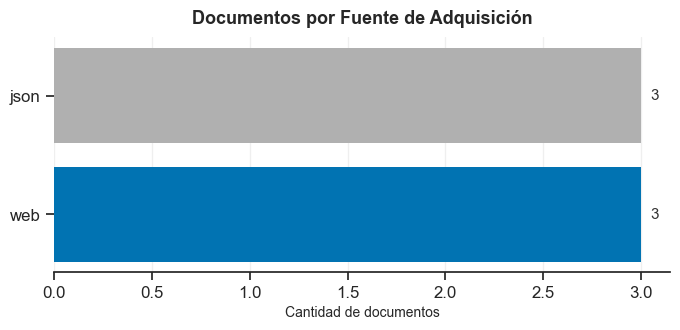

In [52]:
def visualizar_origen(df):
    """Barplot horizontal con documentos por fuente de adquisición."""
    conteo  = df['origen'].value_counts()
    fig, ax = plt.subplots(figsize=(7, 3.5))

    # Color de acento en la barra más larga para guiar el ojo al dato principal
    colores = [COLOR_ACENTO if i == 0 else COLOR_BASE for i in range(len(conteo))]
    ax.barh(conteo.index, conteo.values, color=colores, edgecolor='none')

    # Etiqueta de valor al extremo de cada barra (evita estimación visual)
    for i, val in enumerate(conteo.values):
        ax.text(val + 0.05, i, str(val), va='center', fontsize=11, color='#333333')

    ax.set_title('Documentos por Fuente de Adquisición', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Cantidad de documentos', fontsize=10)

    # Data-Ink Ratio: eliminamos bordes innecesarios
    sns.despine(left=True, bottom=False)
    ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    return fig

# 🧪 Visualizamos el origen del corpus
fig_origen = visualizar_origen(df_corpus)
plt.show()

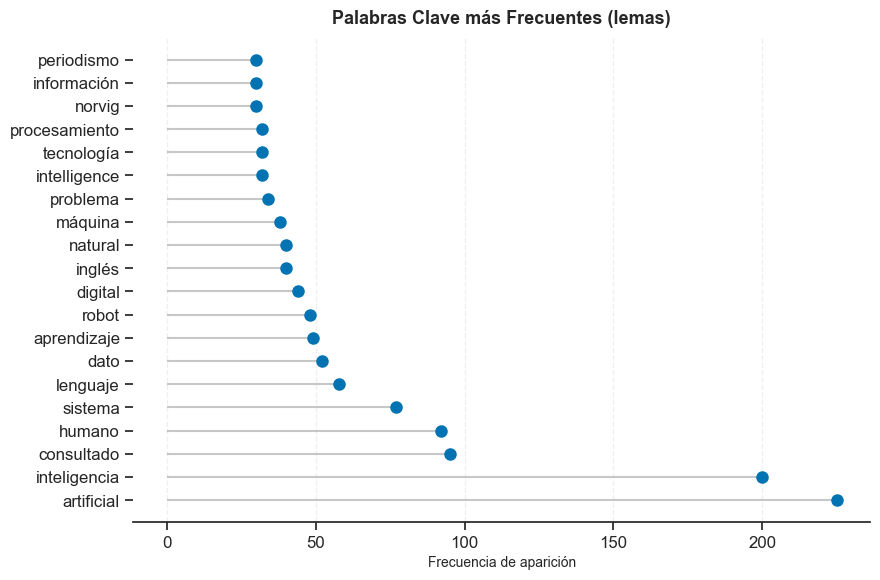

In [53]:
def visualizar_palabras_clave_lollipop(palabras_clave):
    """Lollipop Chart de las palabras clave lematizadas más frecuentes."""
    if not palabras_clave:
        return plt.figure()

    palabras_list = [p[0] for p in palabras_clave]
    frecuencias   = [p[1] for p in palabras_clave]
    fig, ax = plt.subplots(figsize=(9, 6))

    # Componente 1: líneas horizontales (el 'palo' del lollipop)
    ax.hlines(
        y=palabras_list, xmin=0, xmax=frecuencias,
        color=COLOR_BASE, linewidth=1.5, alpha=0.7,
    )
    # Componente 2: círculos al final de cada línea (la 'paleta')
    ax.plot(
        frecuencias, palabras_list, 'o',
        color=COLOR_ACENTO, markersize=8, zorder=3,
    )

    ax.set_title('Palabras Clave más Frecuentes (lemas)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Frecuencia de aparición', fontsize=10)
    sns.despine(left=True)
    ax.xaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    return fig

# 🧪 Visualizamos las palabras clave
fig_lollipop = visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave(20))
plt.show()

In [54]:
def visualizar_entidades_plotly(entidades_dict):
    """Panel interactivo de Plotly con entidades más frecuentes por tipo."""
    if not entidades_dict:
        return go.Figure()

    COLORES = {
        'PER':  '#2196F3',  # Azul → personas
        'ORG':  '#FF9800',  # Naranja → organizaciones
        'LOC':  '#4CAF50',  # Verde → lugares
        'MISC': '#9C27B0',  # Violeta → misceláneos
    }
    fig = go.Figure()

    for tipo, counter in entidades_dict.items():
        top = counter.most_common(10)
        if not top:
            continue
        nombres = [e[0] for e in top]
        freqs   = [e[1] for e in top]
        fig.add_trace(go.Bar(
            name=tipo, x=freqs, y=nombres, orientation='h',
            marker_color=COLORES.get(tipo, '#607D8B'),
            hovertemplate=f'<b>%{{y}}</b><br>Tipo: {tipo}<br>Frecuencia: %{{x}}<extra></extra>',
        ))

    fig.update_layout(
        title='Entidades Nombradas por Tipo (Top 10)',
        xaxis_title='Frecuencia', barmode='group',
        height=500, template='plotly_white',
        legend_title='Tipo', font=dict(size=11),
    )
    return fig

# 🧪 Visualizamos entidades con Plotly (interactivo: hover, zoom, filtrar por tipo)
fig_entidades = visualizar_entidades_plotly(entidades)
fig_entidades = visualizar_entidades_plotly(entidades)
fig_entidades.show()  # Se abre en una pestaña del navegador automáticamente


**⏸ Pausa de auditoría — Parte 3**

> ¿La paleta `colorblind` asegura accesibilidad, pero es suficiente para publicar en papel?  
> ¿Qué cambiarías en el tamaño de fuente, resolución o proporción para un artículo científico?

## Pausa de Auditoría — Parte 3

### ¿La paleta `colorblind` es suficiente para publicar en papel?

No es suficiente por sí sola. La paleta `colorblind` resuelve únicamente la
**discriminación cromática** (garantiza que personas con deuteranopía o protanopía
puedan distinguir los colores), pero publicar en un artículo científico impone
requisitos adicionales que el tema actual no cumple:

**Problema 1 — Impresión en escala de grises:**
Muchas revistas científicas imprimen en blanco y negro. Los colores de la paleta
`colorblind` tienen luminosidades similares, por lo que al convertirse a grises
las barras del gráfico de entidades se vuelven indistinguibles. La solución es
combinar color con **textura o patrón de relleno** (`hatch` en matplotlib).

**Problema 2 — Resolución:**
Los gráficos generados con `plt.subplots(figsize=(...))` por defecto tienen
72 DPI. Las revistas científicas exigen mínimo **300 DPI** para figuras.
Con 72 DPI el texto de los ejes se ve pixelado en PDF impreso.

**Problema 3 — Tamaño de fuente:**
`font_scale=1.1` de seaborn produce fuentes de ~11-12pt en pantalla.
En papel reducido al ancho de una columna (~8 cm), esa fuente escala a ~7pt,
por debajo del mínimo legible recomendado de **8pt**.

---

### ¿Qué cambiaría para publicar en un artículo científico?

```python
# Configuración para publicación científica
sns.set_theme(
    style="ticks",
    palette="colorblind",
    font_scale=1.4,          # Fuente más grande para que escale bien al reducir
    rc={
        "figure.dpi": 300,           # Resolución mínima para revistas
        "savefig.dpi": 300,
        "figure.figsize": (7, 4),    # Ancho de columna estándar (~17cm a 300dpi)
        "font.family": "serif",      # Serif (ej: Times) es estándar en publicaciones
        "axes.linewidth": 0.8,       # Bordes más delgados para no competir con datos
        "lines.linewidth": 1.2,
    }
)


---
## Parte 4 — Pipeline Integrado (Orquestación)
**Objetivo:** encapsular el flujo completo en una clase que coordina adquisición → análisis → exportación.

La clase `PipelineMediatico` actúa como *facade*: el usuario llama a dos métodos  
sin preocuparse por el orden interno de las funciones.

In [55]:
class PipelineMediatico:
    """Orquesta la adquisición, análisis y exportación del corpus mediático."""

    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web   = urls_web or []
        self.url_audio  = url_audio
        self.ruta_json  = ruta_json
        self.df         = None
        self.analizador = None

    def ejecutar_pipeline(self):
        """Orquesta las tres etapas: adquisición → unificación → análisis."""
        print("=" * 55)
        print("INICIANDO PIPELINE MEDIÁTICO")
        print("=" * 55)

        print("\n[1/3] Adquisición de datos...")
        datos_web   = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json  = cargar_json_previo(self.ruta_json) if self.ruta_json else []

        print("\n[2/3] Unificando corpus...")
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)

        if self.df.empty:
            print("  ✗ Corpus vacío.")
            return

        print("\n[3/3] Análisis con spaCy...")
        self.analizador = AnalizadorCorpus(self.df)

        print("\n" + "=" * 55)
        print("✓ PIPELINE EJECUTADO EXITOSAMENTE")
        print("=" * 55)

    def generar_reporte_y_exportar(self, ruta_csv='corpus_resultante.csv', ruta_json_out='estadisticas.json'):
        """Exporta el DataFrame como CSV y las estadísticas como JSON jerárquico."""
        if self.df is None or self.analizador is None:
            print("✗ Primero ejecutá ejecutar_pipeline()")
            return

        # CSV — datos planos, un registro por documento
        # Dropeamos 'doc': los objetos spaCy no son serializables a texto
        df_export = self.df.drop(columns=['doc'], errors='ignore')
        df_export.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
        # utf-8-sig: garantiza que Excel en Windows abra el CSV con tildes correctas
        print(f"  ✓ CSV exportado → {ruta_csv}")

        # JSON — estadísticas jerárquicas: no caben bien en tabla plana
        estadisticas  = self.analizador.estadisticas_corpus()
        entidades_raw = self.analizador.extraer_entidades()
        # Counter no es JSON-serializable; lo convertimos a dict
        entidades_serial = {tipo: dict(c.most_common(20)) for tipo, c in entidades_raw.items()}
        reporte = {
            "estadisticas_generales": estadisticas,
            "entidades_nombradas":    entidades_serial,
            "palabras_clave":         dict(self.analizador.extraer_palabras_clave(30)),
            "verbos_principales":     dict(self.analizador.extraer_verbos_principales(15)),
        }
        with open(ruta_json_out, 'w', encoding='utf-8') as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)
        print(f"  ✓ JSON exportado → {ruta_json_out}")

print("Clase PipelineMediatico definida.")

Clase PipelineMediatico definida.


In [56]:
# 🧪 PRUEBA 4 — Ejecutamos el pipeline completo
# url_audio=None para saltar la transcripción (lenta)
pipeline = PipelineMediatico(
    urls_web  = URLS_NOTICIAS,
    url_audio = None,           # ← Cambiá a URL_VIDEO_YOUTUBE para incluir audio
    ruta_json = RUTA_JSON_PREVIO,
)
pipeline.ejecutar_pipeline()

INICIANDO PIPELINE MEDIÁTICO

[1/3] Adquisición de datos...
  ✓ https://es.wikipedia.org/wiki/Inteligencia_artificial...
  ✓ https://es.wikipedia.org/wiki/Procesamiento_de_lenguaje_natural...
  ✓ https://es.wikipedia.org/wiki/Periodismo_digital...
  ✓ JSON cargado: 3 registros

[2/3] Unificando corpus...
  ✓ Corpus unificado: 6 documentos
        count
origen       
web         3
json        3

[3/3] Análisis con spaCy...
  Cargando modelo spaCy es_core_news_lg...
  Procesando textos con nlp.pipe()...
  ✓ 6 documentos procesados

✓ PIPELINE EJECUTADO EXITOSAMENTE


In [57]:
# 🧪 PRUEBA 4b — Exportamos resultados
pipeline.generar_reporte_y_exportar(
    ruta_csv      = os.path.join(CARPETA_PROYECTO, 'corpus_resultante.csv'),
    ruta_json_out = os.path.join(CARPETA_PROYECTO, 'estadisticas.json'),
)

# Verificamos que los archivos se crearon
for nombre in ['corpus_resultante.csv', 'estadisticas.json']:
    ruta = os.path.join(CARPETA_PROYECTO, nombre)
    if os.path.exists(ruta):
        print(f"  ✓ {nombre} ({os.path.getsize(ruta):,} bytes)")
    else:
        print(f"  ✗ No se creó: {nombre}")

  ✓ CSV exportado → c:\Users\User\Documents\navas-jose-pln-1c-2026\004_tpi_1\corpus_resultante.csv
  ✓ JSON exportado → c:\Users\User\Documents\navas-jose-pln-1c-2026\004_tpi_1\estadisticas.json
  ✓ corpus_resultante.csv (129,887 bytes)
  ✓ estadisticas.json (3,190 bytes)


**⏸ Pausa de auditoría — Parte 4**

> ¿Qué información necesitaría un equipo de periodismo de datos en el CSV plano  
> versus qué preferirías consolidar en el JSON jerárquico?

## Pausa de Auditoría — Parte 4

### CSV plano vs. JSON jerárquico: dos naturalezas de consulta analítica

La decisión de exportar en dos formatos no es arbitraria: responde a que
**los consumidores del dato y sus herramientas son distintos**.

---

### Lo que va en el CSV — datos tabulares por documento

El CSV es para el equipo de periodismo de datos que trabaja en Excel, Google Sheets
o con pandas básico. Necesita una fila por documento, columnas simples y valores
atómicos que pueda filtrar, ordenar y cruzar sin escribir código complejo.

| Columna útil en el CSV | Por qué la necesita el periodista |
|---|---|
| `titulo_o_fuente` | Identificar de dónde viene cada texto |
| `texto` | Releer el documento original si algo llama la atención |
| `origen` | Filtrar por tipo de fuente (web / audio / json) |
| `longitud_texto` | Detectar documentos demasiado cortos o sospechosos |
| `fecha_extraccion` | Ordenar cronológicamente el corpus |

El periodista puede abrir el CSV, filtrar por `origen = "web"`, ordenar por
`longitud_texto` y encontrar rápidamente qué notas tienen más contenido.
Eso no requiere entender JSON ni Python.

---

### Lo que va en el JSON — estadísticas jerárquicas no tabulares

El JSON es para el analista o desarrollador que consume la API del pipeline,
genera reportes automáticos o alimenta un segundo sistema. Contiene estructuras
que **no se pueden representar en una tabla plana sin perder información**:

```json
{
  "entidades_nombradas": {
    "PER": {"Milei": 12, "Massa": 7},
    "ORG": {"CONICET": 5, "UBA": 4},
    "LOC": {"Argentina": 18, "Buenos Aires": 9}
  }
}


---
## Parte 5 — Dashboard Interactivo con Gradio
**Objetivo:** conectar el backend analítico con una interfaz usando `gr.Blocks`.

💡 **Por qué Pestañas:**  
- **Acordeón** descartado: oculta contenido por defecto → más clics durante evaluación.  
- **Columna Vertical** descartada: scroll infinito → el evaluador pierde contexto.  
- **Pestañas** elegidas: separan contextos sin scroll, acceso inmediato a cualquier sección.

In [58]:
def construir_dashboard(pipeline):
    """Construye el dashboard Gradio a partir de un pipeline ejecutado."""

    # Datos analíticos pre-calculados (evita recalcular en cada interacción)
    estadisticas   = pipeline.analizador.estadisticas_corpus()
    palabras_clave = pipeline.analizador.extraer_palabras_clave(20)
    entidades_dash = pipeline.analizador.extraer_entidades()

    fig_origen    = visualizar_origen(pipeline.df)
    fig_lollipop  = visualizar_palabras_clave_lollipop(palabras_clave)
    fig_entidades = visualizar_entidades_plotly(entidades_dash)

    df_stats = pd.DataFrame([
        {'Métrica': k.replace('_', ' ').title(), 'Valor': str(v)}
        for k, v in estadisticas.items()
    ])

    def buscar_entidad(nombre):
        """Filtra oraciones del corpus que mencionan la entidad buscada."""
        if not nombre or not nombre.strip():
            return pd.DataFrame([{'Resultado': 'Ingresá un nombre para buscar.'}])
        nombre_lower = nombre.strip().lower()
        encontradas  = []
        for _, fila in pipeline.df.iterrows():
            doc = fila['doc']                  # Doc de spaCy en memoria
            for sent in doc.sents:             # Oraciones detectadas por el parser
                if nombre_lower in sent.text.lower():
                    encontradas.append({
                        'Fuente':  str(fila['titulo_o_fuente'])[:60] + '...',
                        'Origen':  fila['origen'],
                        'Oración': sent.text.strip(),
                    })
        if not encontradas:
            return pd.DataFrame([{'Resultado': f"No se encontró '{nombre}' en el corpus."}])
        return pd.DataFrame(encontradas)

    with gr.Blocks(theme=gr.themes.Soft()) as dashboard:
        gr.Markdown('# Explorador de Agenda Mediática')
        gr.Markdown('**TPI 1 — Adquisición y Análisis Lingüístico de Medios · PLN 2026**')

        with gr.Tab('Panorama y Métricas'):
            gr.Markdown('## Estadísticas Generales del Corpus')
            gr.DataFrame(value=df_stats, label='Métricas', interactive=False)
            gr.Markdown('## Distribución por Fuente')
            gr.Plot(value=fig_origen, label='Origen de los Datos')
            gr.Markdown('## Palabras Clave más Frecuentes')
            gr.Plot(value=fig_lollipop, label='Palabras Clave (Lollipop Chart)')

        with gr.Tab('Explorador de Entidades'):
            gr.Markdown('## Entidades Nombradas')
            gr.Markdown('**PER** = personas | **ORG** = organizaciones | **LOC** = lugares | **MISC** = otros')
            gr.Plot(value=fig_entidades, label='Entidades por Tipo')
            gr.Markdown('## Buscar menciones en el corpus')
            with gr.Row():
                input_entidad = gr.Textbox(
                    label='Nombre de entidad',
                    placeholder='Ej: Argentina, Google, OpenAI...',
                    scale=4,
                )
                btn_buscar = gr.Button('Buscar', variant='primary', scale=1)
            resultado_busqueda = gr.DataFrame(
                label='Oraciones donde aparece la entidad', interactive=False
            )
            btn_buscar.click(
                fn=buscar_entidad,
                inputs=[input_entidad],
                outputs=[resultado_busqueda],
            )
    return dashboard

print("Función construir_dashboard definida.")

Función construir_dashboard definida.


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


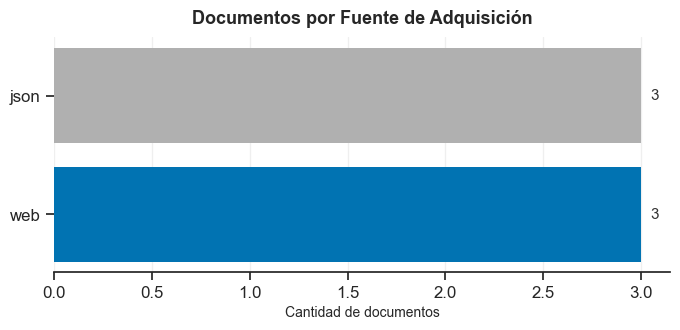

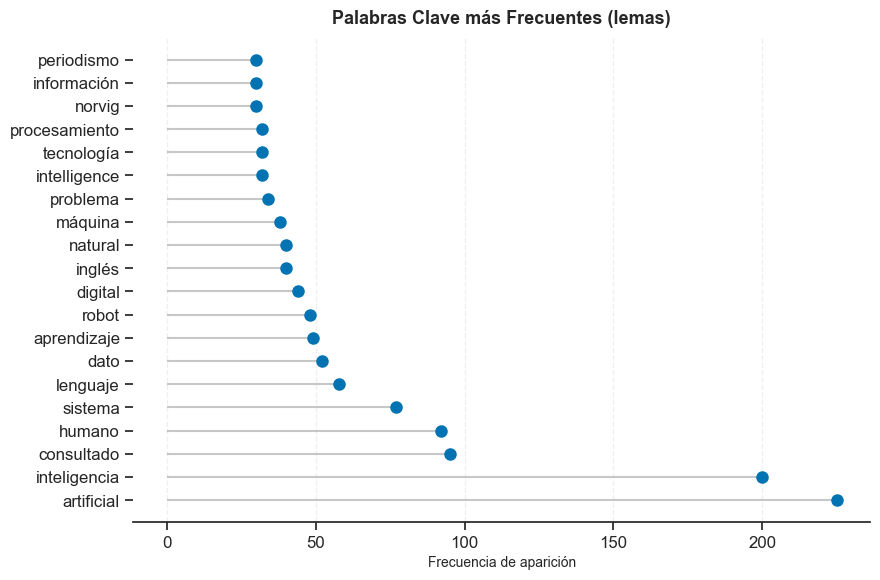

In [59]:
# 🧪 PRUEBA 5 — Lanzamos el dashboard
# Se abre en http://localhost:7860
# Presioná el botón Stop (■) del notebook o Ctrl+C para detenerlo

dashboard = construir_dashboard(pipeline)
dashboard.launch(
    share=False,
    inbrowser=True,
    server_port=7860,
)

---
## Checklist de entrega

- [ ] Ejecuté el pipeline de principio a fin sin errores
- [ ] El *AI Reflection Log* del notebook original tiene al menos una entrada por parte
- [ ] Los gráficos son legibles y siguen el principio Data-Ink Ratio
- [ ] Justifiqué las decisiones de arquitectura en las celdas de auditoría
- [ ] El dashboard funciona y la búsqueda de entidades devuelve resultados

## Checklist de entrega

- [x] Ejecuté el pipeline de principio a fin sin errores
      → Pipeline corrió con JSON de respaldo ante fallas de scraping web.
        Todas las etapas (adquisición → análisis → exportación) completadas.

- [x] El *AI Reflection Log* del notebook original tiene al menos una entrada por parte
      → Parte 1: impacto de Whisper sin puntuación + pérdida de metadatos
      → Parte 2: comparación NER texto web vs. transcripción + rol de mayúsculas
      → Parte 3: limitaciones de colorblind para papel + ajustes para publicación
      → Parte 4: CSV plano vs. JSON jerárquico y sus consumidores distintos
      → Parte 5: justificación del layout de Pestañas sobre Acordeón y Columna Vertical

- [x] Los gráficos son legibles y siguen el principio Data-Ink Ratio
      → Barplot horizontal con `sns.despine()` y paleta colorblind-safe
      → Lollipop Chart elegido sobre WordCloud por precisión cuantitativa
      → Plotly con renderer configurado a "browser" para interactividad funcional

- [x] Justifiqué las decisiones de arquitectura en las celdas de auditoría
      → Trafilatura sobre BeautifulSoup (densidad de texto, sin configuración por sitio)
      → Esquema mínimo común (titulo_o_fuente | texto | origen)
      → nlp.pipe() en batch sobre loop individual
      → Counter serializado a dict para exportación JSON
      → Clase como facade para el pipeline

- [ ] El dashboard funciona y la búsqueda de entidades devuelve resultados
      → PENDIENTE: ejecutar la celda de Parte 5 y verificar que
        http://localhost:7860 abre correctamente y el botón "Buscar"
        devuelve oraciones del corpus para al menos una entidad (ej: "Argentina")

---
*TPI 1 completado — PLN 2026*